# Frouth Stability analysis from a video

In [46]:
# importing libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import cv2 as cv
import matplotlib.animation as animation

# Priliminary test

In [47]:
# reading the video
cap = cv.VideoCapture('rl4_pb17-4.mp4')

# getting the frame rate
fps = cap.get(cv.CAP_PROP_FPS)

print(f"video fps: {fps}")

# getting the frame count
frame_count = int(cap.get(cv.CAP_PROP_FRAME_COUNT))

print(f"video frame count: {frame_count}")



video fps: 29.703158414733778
video frame count: 938


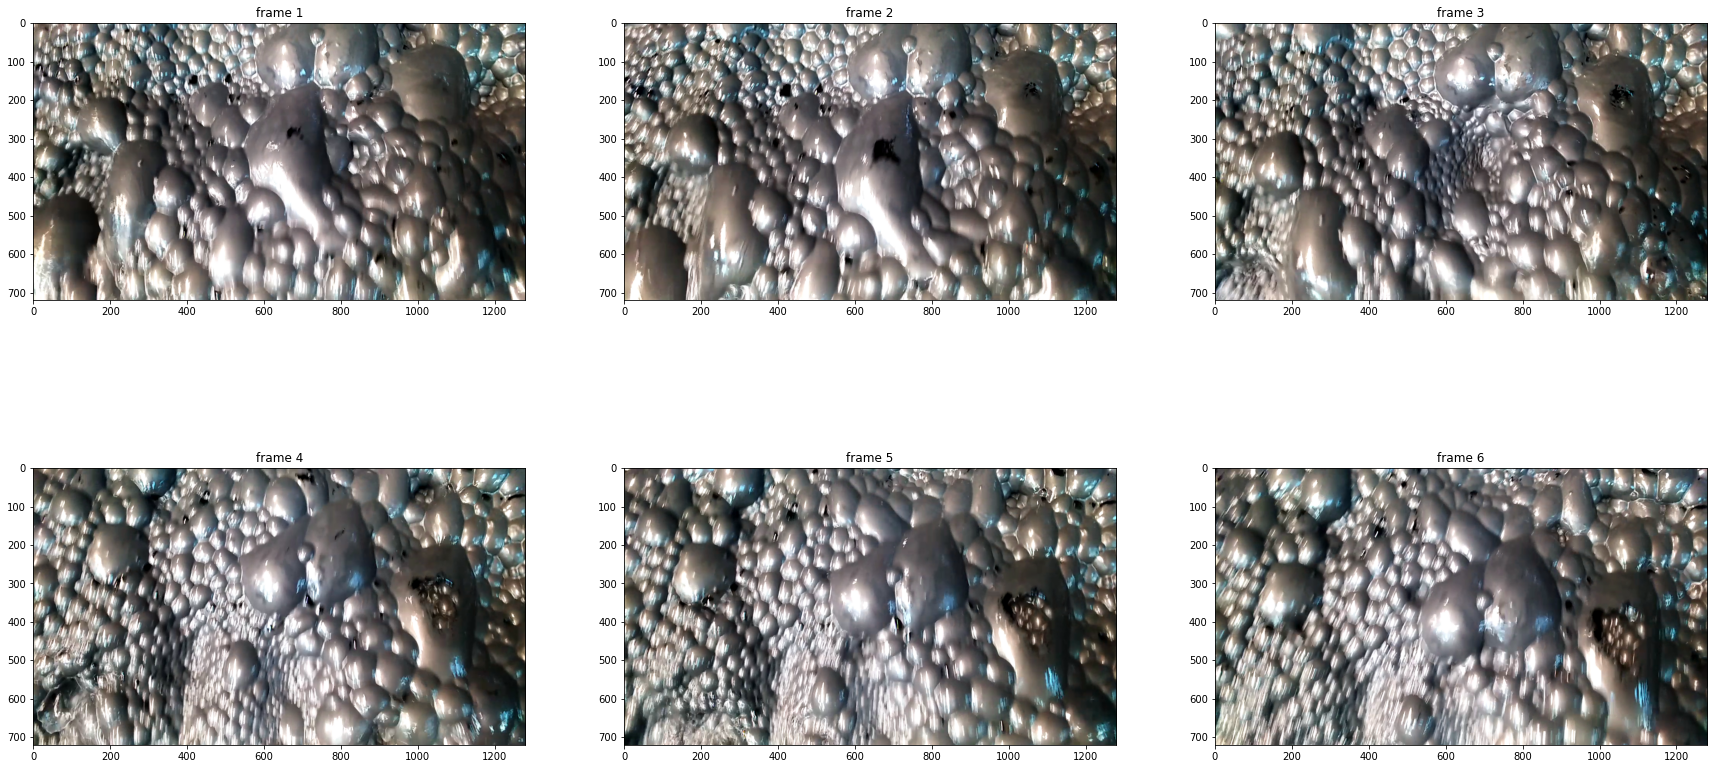

In [48]:
# getting frames from the second 7 to 7.5
cap.set(cv.CAP_PROP_POS_MSEC, 7500)
ret, frame = cap.read()
cap.set(cv.CAP_PROP_POS_MSEC, 7600)
ret, frame2 = cap.read()
cap.set(cv.CAP_PROP_POS_MSEC, 7700)
ret, frame3 = cap.read()
cap.set(cv.CAP_PROP_POS_MSEC, 8200)
ret, frame4 = cap.read()
cap.set(cv.CAP_PROP_POS_MSEC, 8300)
ret, frame5 = cap.read()
cap.set(cv.CAP_PROP_POS_MSEC, 8400)
ret, frame6 = cap.read()
# ploting the frames in a 2x2 grid
fig, ax = plt.subplots(2, 3, figsize=(30, 15))
ax[0, 0].imshow(frame)
ax[0, 0].set_title('frame 1')
ax[0, 1].imshow(frame2)
ax[0, 1].set_title('frame 2')
ax[0, 2].imshow(frame3)
ax[0, 2].set_title('frame 3')
ax[1, 0].imshow(frame4)
ax[1, 0].set_title('frame 4')
ax[1, 1].imshow(frame5)
ax[1, 1].set_title('frame 5')
ax[1, 2].imshow(frame6)
ax[1, 2].set_title('frame 6')

plt.show()


In [49]:
# converting the frames to grayscale
gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
gray2 = cv.cvtColor(frame2, cv.COLOR_BGR2GRAY)
gray3 = cv.cvtColor(frame3, cv.COLOR_BGR2GRAY)
gray4 = cv.cvtColor(frame4, cv.COLOR_BGR2GRAY)
gray5 = cv.cvtColor(frame5, cv.COLOR_BGR2GRAY)
gray6 = cv.cvtColor(frame6, cv.COLOR_BGR2GRAY)



## Average intensity between frame 1 and 2 

In [50]:
# Calculating the average of the grayscale frames
avg = (gray + gray2)/2

# claculating the avrage intensity of the average frame
avg_intensity = np.mean(avg)

avg_intensity

64.288984375

# Average intensity between frame 2 and 3

In [51]:
avg2 = (gray2 + gray3)/2
avg_intensity2 = np.mean(avg2)

avg_intensity2

66.01447808159722

# Average intensity between frame 2 and 4

In [57]:
avg3 = (gray2 + gray4)/2
avg_intensity3 = np.mean(avg3)

avg_intensity3

66.15469292534722

In [28]:
def applied_method(cap, frames_to_take):
    # getting the frame rate
    fps = cap.get(cv.CAP_PROP_FPS)
    # getting the frame count
    frame_count = int(cap.get(cv.CAP_PROP_FRAME_COUNT))
    
    frames = []
    gray_frames = []
    for i in range(0, frame_count, frames_to_take):
        ls = []
        ls2 = []
        for j in range(i,i+frames_to_take):
            ret, frame = cap.read()
            if ret == False:
                break
            else:
                gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
                ls2.append(gray)
                ls.append(frame)
        if len(ls) == frames_to_take:
            gray_frames.append(ls2)
            frames.append(ls)

    # avg of each row in gray_frames
    avg_ls = []
    for row in gray_frames:
        for i in range(len(row)):
            if i == 0:
                sum = row[i]
            else:
                sum += row[i]
        avg_ls.append(sum/len(row))



    # calculate the average intensity of the average frames
    avg_intensity_frames = []
    
    for i in range(len(avg_ls)):
        avg_intensity_frames.append(np.mean(avg_ls[i]))


    return avg_intensity_frames, frames



# Results for the first video

### The results are presented in plots, each plot represents the fluctuation of the average intensity, x-axis is the frames and y-axis is the average intensity.


In [35]:
# reading the video
cap = cv.VideoCapture('rl4_pb17-4.mp4')

frames_to_take = input("Enter the number of frames to take: ")
frames_to_take = int(frames_to_take)

# getting the frame rate
fps = cap.get(cv.CAP_PROP_FPS)

print(f"video fps: {fps}")

# getting the frame count
frame_count = int(cap.get(cv.CAP_PROP_FRAME_COUNT))

print(f"video frame count: {frame_count} , values = {frame_count/frames_to_take}")

# applying the method to the video
avg_intensity_frames, frames = applied_method(cap, frames_to_take)



video fps: 29.703158414733778
video frame count: 938 , values = 134.0


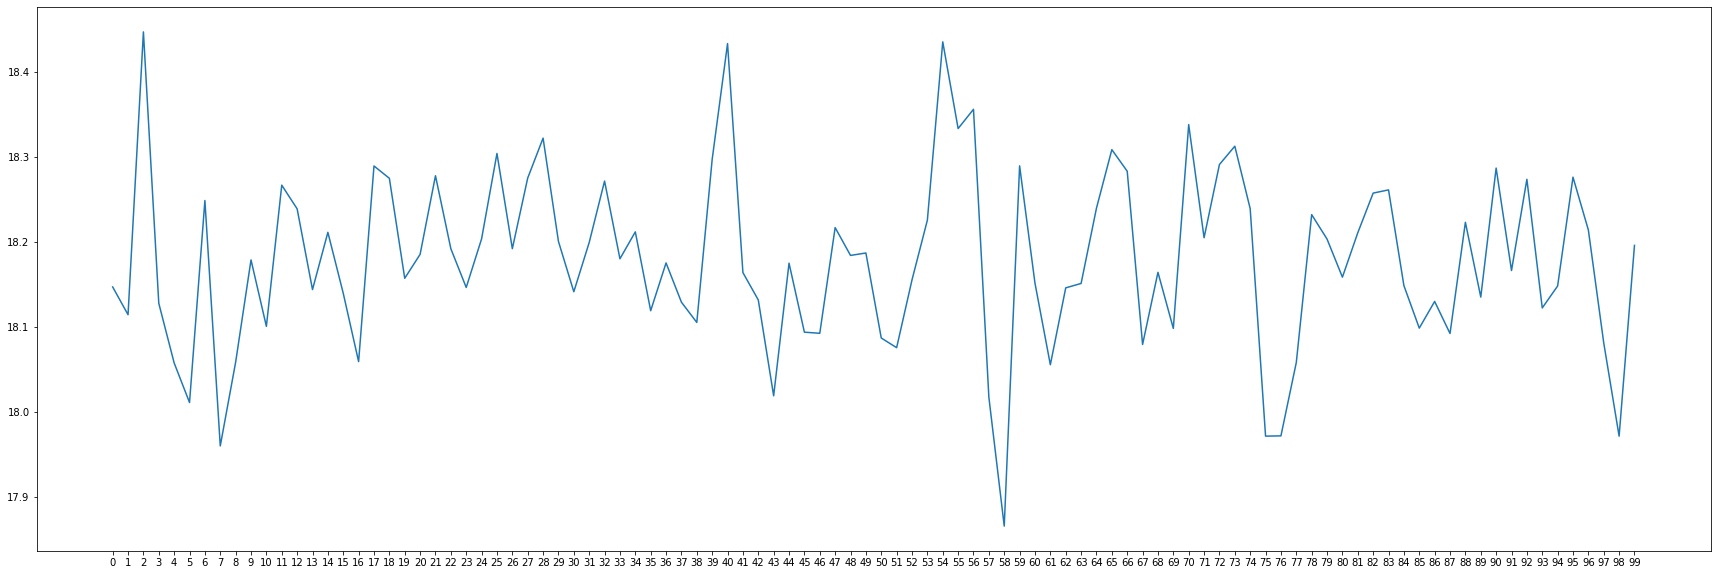

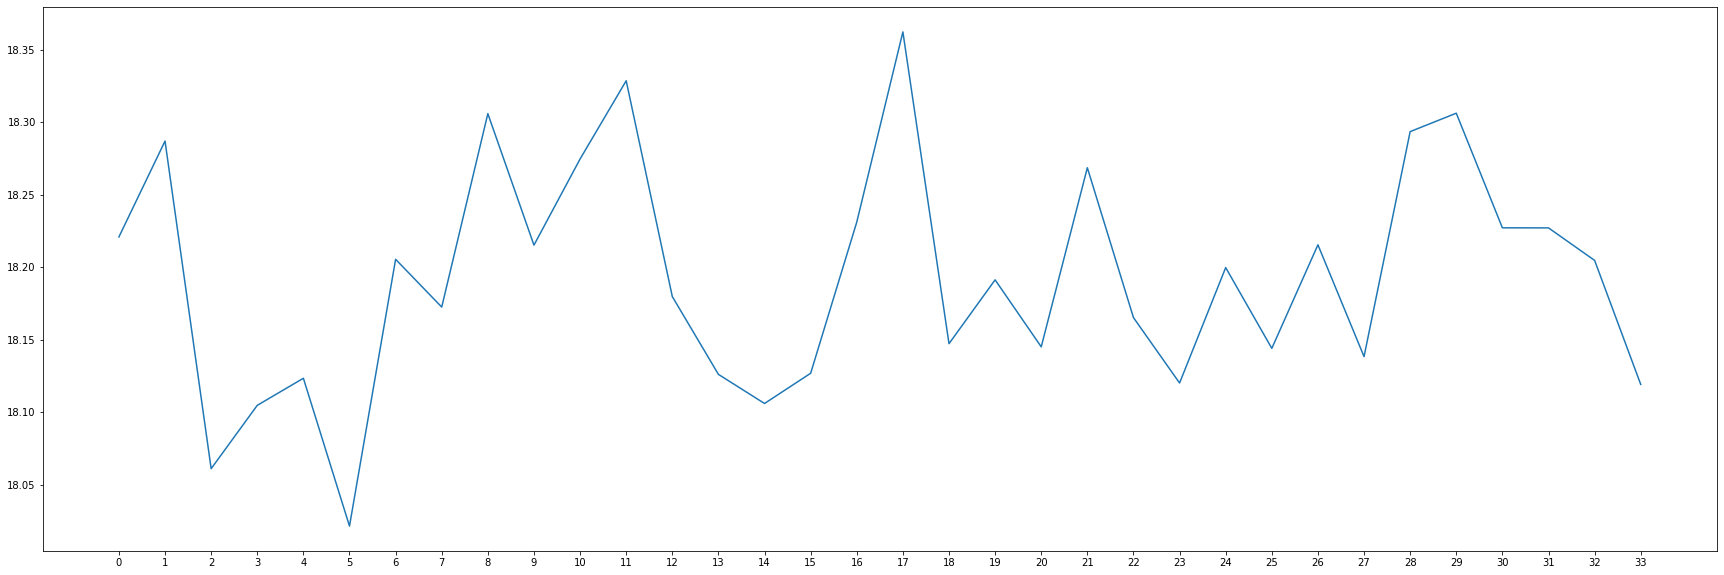

In [36]:

# ploting the average intensity of the average frames
if len(avg_intensity_frames) > 100:
    for i in range(0, len(avg_intensity_frames), 100):
        plt.figure(figsize=(30, 10))
        plt.xticks(np.arange(0, len(avg_intensity_frames[i:i+100]), 1))
        plt.plot(avg_intensity_frames[i:i+100])
        plt.show()
else:
    plt.figure(figsize=(20, 10))
    plt.xticks(np.arange(0, len(avg_intensity_frames), 1))
    plt.plot(avg_intensity_frames)
    plt.show()

# Results for the second video

### The results are presented in plots, each plot represents the fluctuation of the average intensity, x-axis is the frames and y-axis is the average intensity.


In [37]:
cap2 = cv.VideoCapture('rl4_pb8-7.mp4')

# getting the frame rate
fps2 = cap2.get(cv.CAP_PROP_FPS)

print(f"video fps: {fps}")

# getting the frame count
frame_count2 = int(cap2.get(cv.CAP_PROP_FRAME_COUNT))

print(f"video frame count: {frame_count2} , values = {frame_count2/frames_to_take}")

# applying the method to the video
avg_intensity_frames2, frames2 = applied_method(cap2, frames_to_take)


video fps: 29.703158414733778
video frame count: 898 , values = 128.28571428571428


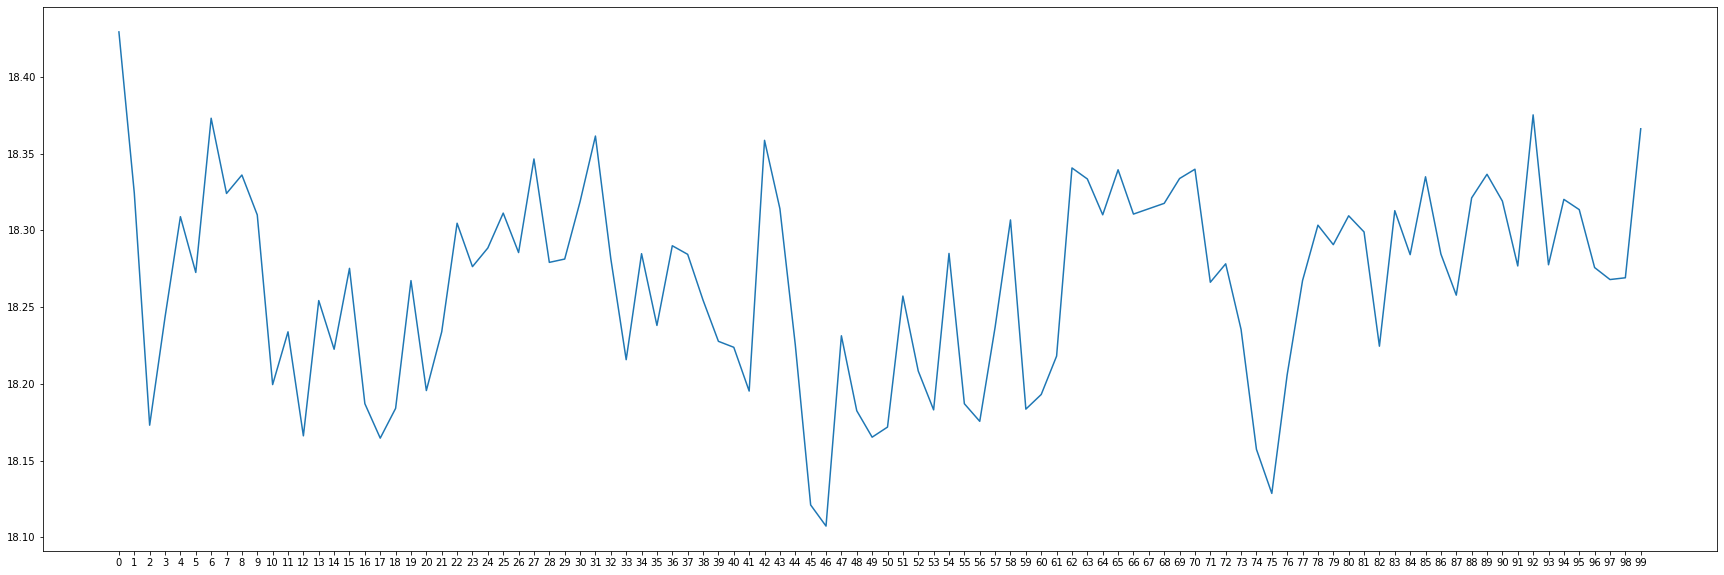

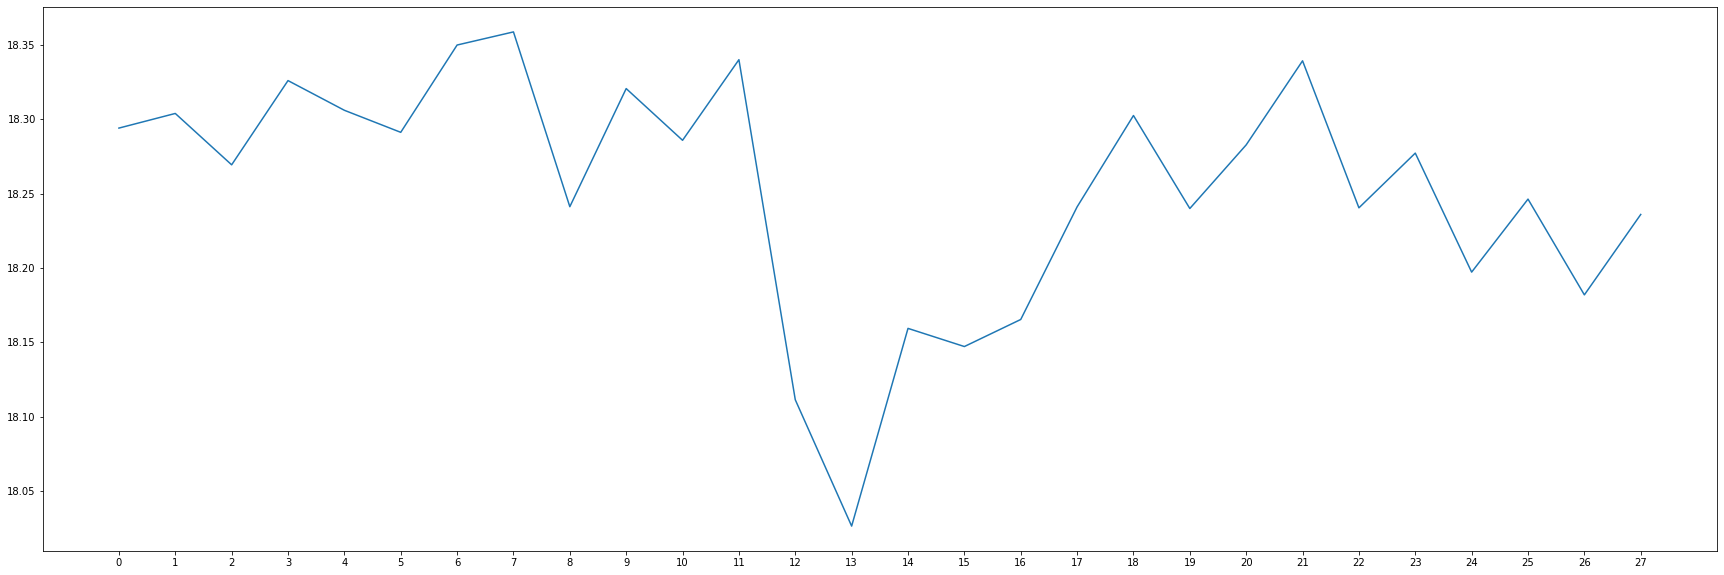

In [38]:

# ploting the average intensity of the average frames
if len(avg_intensity_frames2) > 100:
    for i in range(0, len(avg_intensity_frames2), 100):
        plt.figure(figsize=(30, 10))
        plt.xticks(np.arange(0, len(avg_intensity_frames2[i:i+100]), 1))
        plt.plot(avg_intensity_frames2[i:i+100])
        plt.show()
else:
    plt.figure(figsize=(20, 10))
    plt.xticks(np.arange(0, len(avg_intensity_frames2), 1))
    plt.plot(avg_intensity_frames2)
    plt.show()

# We can tell that there is a lot of noise in our results due to the velocity effect. so we need to reduce the noise.

## To be implemented
#### trying to stabilize the video by using the optical flow method